Nombre de points (Statut=1) : 19738
Vitesse max : 27.2 m/s
Puissance max : 1,502,168 W
Coefficient k (P = k·V³) : 185.40 W·s³/m³


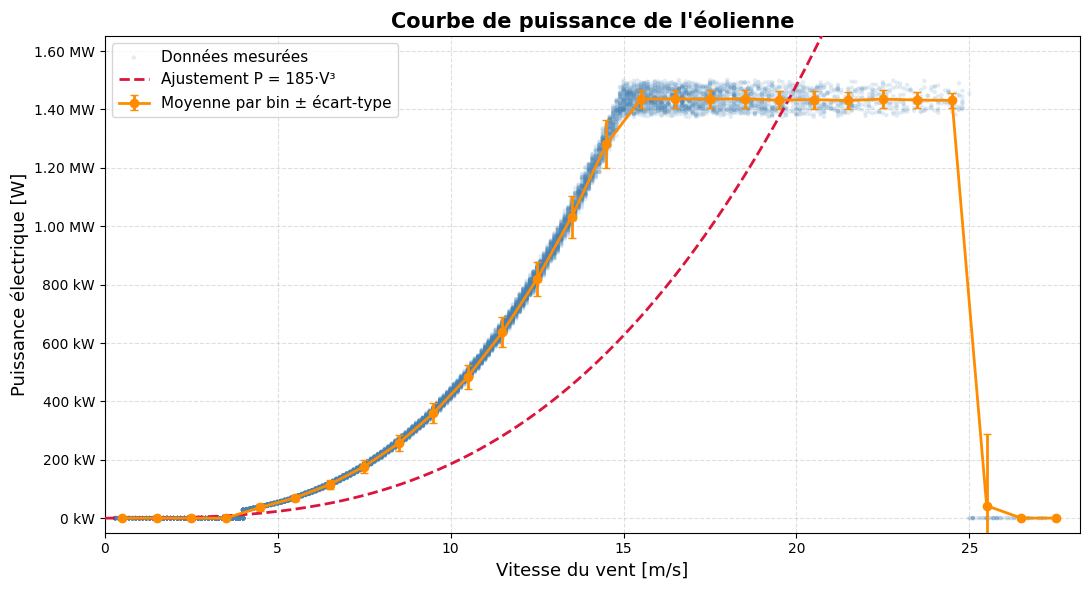

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import binned_statistic

# --- Chargement des données ---
df = pd.read_csv('donnees.txt', sep='\t', skipinitialspace=True)
df.columns = df.columns.str.strip()

# Garder uniquement les lignes avec Statut == 1
df = df[df['Statut'] == 1].copy()

vitesse  = df['Vitess_Vent_[m/s]'].values
puissance = df['Pelec[w]'].values

print(f"Nombre de points (Statut=1) : {len(df)}")
print(f"Vitesse max : {vitesse.max():.1f} m/s")
print(f"Puissance max : {puissance.max():,.0f} W")

# --- Moyenne par bins de 1 m/s (courbe de puissance IEC) ---
bins = np.arange(0, vitesse.max() + 2, 1)
mean_p, bin_edges, _ = binned_statistic(vitesse, puissance, statistic='mean', bins=bins)
std_p,  _,         _ = binned_statistic(vitesse, puissance, statistic='std',  bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

valid = ~np.isnan(mean_p)
vc = bin_centers[valid]
mp = mean_p[valid]
sp = std_p[valid]

# --- Ajustement cubique P = k * V^3 (sur points non nuls) ---
mask = puissance > 0
coeffs = np.polyfit(vitesse[mask]**3, puissance[mask], 1)
k = coeffs[0]
v_fit = np.linspace(0, vitesse.max() + 1, 300)
p_fit = np.where(v_fit >= 2.5, k * v_fit**3, 0)

print(f"Coefficient k (P = k·V³) : {k:.2f} W·s³/m³")

# --- Tracé ---
fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(vitesse, puissance, color='steelblue', alpha=0.15,
           edgecolors='none', s=10, label='Données mesurées', zorder=2)

ax.errorbar(vc, mp, yerr=sp, fmt='o-', color='darkorange', linewidth=2,
            markersize=6, capsize=3, label='Moyenne par bin ± écart-type', zorder=4)

ax.plot(v_fit, p_fit, '--', color='crimson', linewidth=2,
        label=f'Ajustement P = {k:.0f}·V³', zorder=4)

ax.set_xlabel('Vitesse du vent [m/s]', fontsize=13)
ax.set_ylabel('Puissance électrique [W]', fontsize=13)
ax.set_title("Courbe de puissance de l'éolienne", fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim(0, vitesse.max() + 1)
ax.set_ylim(-50000, puissance.max() * 1.1)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.2f} MW' if x >= 1e6 else f'{x/1e3:.0f} kW')
)

plt.tight_layout()
plt.savefig('courbe_puissance_eolienne.png', dpi=150, bbox_inches='tight')
plt.show()